# Benchmark de performance: FPS y tiempo de inferencia

Las métricas de `02_Preprocessing_and_Training` y `04_Seed_Variability` comparan los modelos en
términos de **calidad de detección** (mAP50, precision, recall). Sin embargo, como se menciona
en el `README`, uno de los objetivos del proyecto es evaluar la **factibilidad de uso en
escenarios de tiempo real** (drones, dispositivos móviles).

Este notebook mide, para cada arquitectura candidata (variantes **n**/**s** de YOLOv8, YOLO11 y
YOLO26), el **tiempo de inferencia por imagen** y los **FPS** equivalentes, sobre el mismo
hardware y con el mismo tamaño de imagen (`imgsz=640`) usado durante el entrenamiento.

Se usan los checkpoints `.pt` en la raíz del repo: `yolov8n.pt`, `yolov8s.pt`, `yolo11s.pt`,
`yolo26n.pt` y `yolo26s.pt` son los pesos fine-tuned sobre el dataset de girasoles; `yolo11n.pt`
sigue siendo el checkpoint pre-entrenado (COCO), ya que no se subió una versión fine-tuned. El
costo computacional (FLOPs, número de parámetros, tiempo de inferencia) depende de la
**arquitectura** y no de los pesos, por lo que esto no afecta la comparación de FPS.

## Setup

In [13]:
import os
import glob
import time

import numpy as np
import torch

try:
    from ultralytics import YOLO
except ImportError:
    print("Installing Ultralytics library...")
    !pip install ultralytics
    from ultralytics import YOLO

DATASET_PATH = "sunflower_unified"
VAL_IMAGES_DIR = os.path.join(DATASET_PATH, "valid", "images")

IMGSZ = 640
device_to_use = 0 if torch.cuda.is_available() else "cpu"
device_label = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"Device: {device_label}")

Device: NVIDIA GeForce RTX 3060 Ti


## Modelos a evaluar

Mismas 6 configuraciones que en `04_Seed_Variability` (checkpoints base `.pt`, sin fine-tuning,
ya que la latencia depende de la arquitectura).

In [14]:
MODEL_CHECKPOINTS = {
    "YOLOv8n": "yolov8n.pt",
    "YOLOv8s": "yolov8s.pt",
    "YOLO11n": "yolo11n.pt",
    "YOLO11s": "yolo11s.pt",
    "YOLO26n": "yolo26n.pt",
    "YOLO26s": "yolo26s.pt",
}

# yolo11n.pt no tiene una versión fine-tuned (no se subió), así que si no está presente
# se descarga el checkpoint genérico pre-entrenado en COCO desde Ultralytics.
if not os.path.exists(MODEL_CHECKPOINTS["YOLO11n"]):
    print("Descargando pesos genéricos (COCO) para YOLO11n...")
    YOLO(MODEL_CHECKPOINTS["YOLO11n"])  # dispara la descarga automática del checkpoint

for name, ckpt in MODEL_CHECKPOINTS.items():
    assert os.path.exists(ckpt), f"No se encontró el checkpoint de {name}: {ckpt}"

Descargando pesos genéricos (COCO) para YOLO11n...


## Medición de tiempo de inferencia

Para cada modelo:

1. Se cargan algunas imágenes del set de validación.
2. Se hacen unas pocas corridas de **warmup** (no se miden) para no penalizar al primer modelo
   por la inicialización de CUDA/cuDNN.
3. Se mide el tiempo de `model.predict` para cada imagen, de a una (`batch=1`), que es el caso
   de uso relevante para inferencia en tiempo real sobre un stream de video.

Se reporta media ± desvío estándar del tiempo por imagen (ms) y los FPS equivalentes
(`1000 / tiempo_medio_ms`).

In [16]:
N_WARMUP = 5
N_IMAGES = 200

image_files = sorted(glob.glob(os.path.join(VAL_IMAGES_DIR, "*.jpg")))[:N_IMAGES]
assert len(image_files) > 0, f"No se encontraron imágenes en {VAL_IMAGES_DIR}"
print(f"Usando {len(image_files)} imágenes de validación para el benchmark")


def benchmark_model(checkpoint, image_files, imgsz=IMGSZ, device=device_to_use, n_warmup=N_WARMUP):
    model = YOLO(checkpoint)

    # Warmup: no se mide, solo para estabilizar CUDA/cuDNN
    for img_path in image_files[:n_warmup]:
        model.predict(img_path, imgsz=imgsz, device=device, verbose=False)

    times_ms = []
    for img_path in image_files:
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.perf_counter()

        model.predict(img_path, imgsz=imgsz, device=device, verbose=False)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times_ms.append((time.perf_counter() - start) * 1000)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return np.array(times_ms)


benchmark_rows = []
for name, checkpoint in MODEL_CHECKPOINTS.items():
    times_ms = benchmark_model(checkpoint, image_files)
    mean_ms, std_ms = times_ms.mean(), times_ms.std()
    fps_mean = 1000.0 / mean_ms

    benchmark_rows.append({
        "name": name,
        "mean_ms": mean_ms,
        "std_ms": std_ms,
        "fps": fps_mean,
    })

    print(f"{name:>8}  {mean_ms:6.2f} ± {std_ms:5.2f} ms/img  ->  {fps_mean:6.2f} FPS")

Usando 200 imágenes de validación para el benchmark
 YOLOv8n    7.89 ±  0.83 ms/img  ->  126.81 FPS
 YOLOv8s    8.64 ±  0.44 ms/img  ->  115.71 FPS
 YOLO11n    8.54 ±  0.94 ms/img  ->  117.13 FPS
 YOLO11s    9.15 ±  0.49 ms/img  ->  109.32 FPS
 YOLO26n    9.54 ±  0.59 ms/img  ->  104.88 FPS
 YOLO26s    9.83 ±  0.43 ms/img  ->  101.71 FPS


## Tamaño de los modelos (parámetros y FLOPs)

Complementa el tiempo de inferencia con el tamaño de cada modelo: cantidad de parámetros y
FLOPs (a `imgsz=640`), que ayudan a explicar las diferencias de latencia entre arquitecturas.

In [17]:
from ultralytics.utils.torch_utils import get_flops, get_num_params

for row in benchmark_rows:
    checkpoint = MODEL_CHECKPOINTS[row["name"]]
    model = YOLO(checkpoint)

    row["params_m"] = get_num_params(model.model) / 1e6
    row["flops_g"] = get_flops(model.model, imgsz=IMGSZ)
    del model

    print(f"{row['name']:>8}  {row['params_m']:6.2f} M params  {row['flops_g']:6.1f} GFLOPs")

 YOLOv8n    3.16 M params     8.9 GFLOPs
 YOLOv8s   11.17 M params    28.8 GFLOPs
 YOLO11n    2.62 M params     6.6 GFLOPs
 YOLO11s    9.46 M params    21.7 GFLOPs
 YOLO26n    2.57 M params     6.1 GFLOPs
 YOLO26s   10.01 M params    22.8 GFLOPs


## Gráfico: FPS por modelo

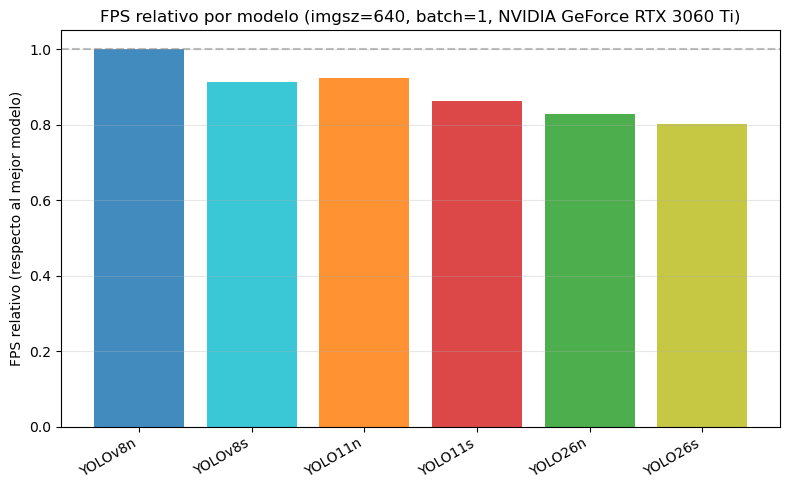

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt

MODEL_COLORS = {
    "YOLOv8n": "tab:blue",
    "YOLOv8s": "tab:cyan",
    "YOLO11n": "tab:orange",
    "YOLO11s": "tab:red",
    "YOLO26n": "tab:green",
    "YOLO26s": "tab:olive",
}

names = [r["name"] for r in benchmark_rows]
fps_values = [r["fps"] for r in benchmark_rows]
colors = [MODEL_COLORS[n] for n in names]

best_fps = max(fps_values)
fps_relative = [fps / best_fps for fps in fps_values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(names, fps_relative, color=colors, alpha=0.85)
ax.set_ylabel("FPS relativo (respecto al mejor modelo)")
ax.set_title(f"FPS relativo por modelo (imgsz={IMGSZ}, batch=1, {device_label})")
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig("benchmark_fps.pdf")
plt.show()

## Tabla en formato LaTeX

In [20]:
lines = []
lines.append(r"\begin{table}[h]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{lcccc}")
lines.append(r"\toprule")
lines.append(r"Modelo & Params (M) & GFLOPs & Tiempo (ms) & FPS \\")
lines.append(r"\midrule")
for row in benchmark_rows:
    lines.append(
        f"{row['name']} & {row['params_m']:.2f} & {row['flops_g']:.1f} & "
        f"${row['mean_ms']:.2f} \\pm {row['std_ms']:.2f}$ & {row['fps']:.1f} \\\\"
    )
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Tiempo de inferencia y FPS por modelo (imgsz=640, batch=1)}")
lines.append(r"\end{table}")

print("\n".join(lines))

\begin{table}[h]
\centering
\begin{tabular}{lcccc}
\toprule
Modelo & Params (M) & GFLOPs & Tiempo (ms) & FPS \\
\midrule
YOLOv8n & 3.16 & 8.9 & $7.89 \pm 0.83$ & 126.8 \\
YOLOv8s & 11.17 & 28.8 & $8.64 \pm 0.44$ & 115.7 \\
YOLO11n & 2.62 & 6.6 & $8.54 \pm 0.94$ & 117.1 \\
YOLO11s & 9.46 & 21.7 & $9.15 \pm 0.49$ & 109.3 \\
YOLO26n & 2.57 & 6.1 & $9.54 \pm 0.59$ & 104.9 \\
YOLO26s & 10.01 & 22.8 & $9.83 \pm 0.43$ & 101.7 \\
\bottomrule
\end{tabular}
\caption{Tiempo de inferencia y FPS por modelo (imgsz=640, batch=1)}
\end{table}
